In [ ]:
!pip install earthengine-api --quiet
!pip install folium --quiet
!pip install geemap --quiet
!pip install tensorflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 28.8 MB/s eta 0:00:00


In [ ]:
# in the files section put either the easy or hard .csv

# Google Colab
from google.colab import output
output.enable_custom_widget_manager()

# Earth Engine & Mapping
import ee
import geemap
import folium
from folium.plugins import MarkerCluster
from folium.plugins import FastMarkerCluster

# Core Python
import json
from datetime import datetime, timedelta

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.utils import class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import (
    Input, Masking, LSTM, Bidirectional, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, BatchNormalization, SpatialDropout1D, LeakyReLU, Reshape
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Masking, Bidirectional, LSTM, Conv1D, BatchNormalization,
    LayerNormalization, Dropout, Dense, GlobalMaxPooling1D,
    GlobalAveragePooling1D, Concatenate, Activation
)

from tensorflow.keras.layers import (
    Input, Masking, Bidirectional, LSTM, LayerNormalization,
    Dropout, Dense, BatchNormalization, Activation,
    GlobalAveragePooling1D, GlobalMaxPooling1D, Concatenate, Add
)
from tensorflow.keras import Model

import tensorflow as tf
from keras import Sequential, Input
from keras.layers import (
    Masking, Bidirectional, LSTM, LayerNormalization,
    Dropout, Dense, BatchNormalization, Activation,
    MultiHeadAttention, GlobalAveragePooling1D
)

ee.Authenticate()
# add your google earth engine project here
ee.Initialize(project='ee-enisbirgili')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [323]:

# add crops_easy.csv and crops_hard.csv

dataset = "easy"
tempo = "mono"

In [324]:

# easier to train on location, less classes
if dataset == "easy":
  aoi = ee.Geometry.Rectangle([
      -90.33133359168521,  # min longitude (west)
      35.56839127741864,   # min latitude (south)
      -90.28652997230044,  # max longitude (east)
      35.59826718872311    # max latitude (north)
  ])
# harder to train on location, more classes
if dataset == "hard":
  aoi = ee.Geometry.Rectangle([
      -77.53475507131758,  # min longitude (west)
      35.924430554035496,   # min latitude (south)
      -77.72152264944258,  # max longitude (east)
      36.047219811319366  # max latitude (north)
  ])

In [325]:
if dataset == "easy":
    df = pd.read_csv("crops_easy.csv")
elif dataset == "hard":
    df = pd.read_csv("crops_hard.csv")

In [326]:
if tempo == "multi":

  df["lon"] = df[".geo"].apply(lambda x: json.loads(x)["coordinates"][0])
  df["lat"] = df[".geo"].apply(lambda x: json.loads(x)["coordinates"][1])
  df["date"] = pd.to_datetime(df["date"])

  df = df.rename(columns={
      "B2": "B2", "B3": "B3", "B4": "B4", "B8": "B8",
      "NDVI": "NDVI",
      "Crop": "CropLabel"
  })

  df = df.drop(columns=[".geo"])
  df = df.sort_values(by=["lat", "lon", "date"])

  print("DataFrame shape:", df.shape)
  print(df.head())

elif tempo == "mono":

  df["lon"] = df[".geo"].apply(lambda x: json.loads(x)["coordinates"][0])
  df["lat"] = df[".geo"].apply(lambda x: json.loads(x)["coordinates"][1])
  df["date"] = pd.to_datetime(df["date"])

  df = df.rename(columns={
      "B2": "B2", "B3": "B3", "B4": "B4", "B8": "B8",
      "NDVI": "NDVI",
      "Crop": "CropLabel"
  })
  df = df.drop(columns=[".geo"])
  df = df.sort_values(by=["lat", "lon", "date"])

  # locations get one timestamp closest to mid-July
  target_date = pd.to_datetime("2024-07-15")

  def select_closest(group):
      return group.iloc[(group["date"] - target_date).abs().argsort().iloc[0]]

  df = df.groupby(["lat", "lon", "cropland"]).apply(select_closest).reset_index(drop=True)

  print("Mono-temporal DataFrame shape:", df.shape)
  print(df.head())


Mono-temporal DataFrame shape: (1579, 10)
                                    system:index   B2   B3   B4    B8  \
0   20240713T163901_20240713T164929_T15SYV_988_0  972  853  501  4334   
1   20240713T163901_20240713T164929_T15SYV_975_0  941  795  454  4576   
2  20240713T163901_20240713T164929_T15SYV_1007_0  937  808  476  3919   
3   20240713T163901_20240713T164929_T16SBE_975_0  941  795  452  4565   
4   20240713T163901_20240713T164929_T16SBE_988_0  975  865  511  4356   

       NDVI  cropland       date        lon        lat  
0  0.792761         5 2024-07-13 -90.296231  35.568320  
1  0.819483         5 2024-07-13 -90.286632  35.568375  
2  0.783390         5 2024-07-13 -90.312775  35.568420  
3  0.819813         5 2024-07-13 -90.286631  35.568426  
4  0.790014         5 2024-07-13 -90.296227  35.568434  


In [327]:

# map taken from USDA crop data layer
crop_label_map = {
    0: "Background",
    1: "Corn",
    2: "Cotton",
    3: "Rice",
    4: "Sorghum",
    5: "Soybeans",
    6: "Sunflower",
    10: "Peanuts",
    11: "Tobacco",
    12: "Sweet Corn",
    13: "Pop or Orn Corn",
    14: "Mint",
    21: "Barley",
    22: "Durum Wheat",
    23: "Spring Wheat",
    24: "Winter Wheat",
    25: "Other Small Grains",
    26: "Dbl Crop WinWht/Soybeans",
    27: "Rye",
    28: "Oats",
    29: "Millet",
    30: "Speltz",
    31: "Canola",
    32: "Flaxseed",
    33: "Safflower",
    34: "Rape Seed",
    35: "Mustard",
    36: "Alfalfa",
    37: "Other Hay/Non Alfalfa",
    38: "Camelina",
    39: "Buckwheat",
    41: "Sugarbeets",
    42: "Dry Beans",
    43: "Potatoes",
    44: "Other Crops",
    45: "Sugarcane",
    46: "Sweet Potatoes",
    47: "Misc Vegs & Fruits",
    48: "Watermelons",
    49: "Onions",
    50: "Cucumbers",
    51: "Chick Peas",
    52: "Lentils",
    53: "Peas",
    54: "Tomatoes",
    55: "Caneberries",
    56: "Hops",
    57: "Herbs",
    58: "Clover/Wildflowers",
    59: "Sod/Grass Seed",
    60: "Switchgrass",
    61: "Fallow/Idle Cropland",
    63: "Forest",
    64: "Shrubland",
    65: "Barren",
    66: "Cherries",
    67: "Peaches",
    68: "Apples",
    69: "Grapes",
    70: "Christmas Trees",
    71: "Other Tree Crops",
    72: "Citrus",
    74: "Pecans",
    75: "Almonds",
    76: "Walnuts",
    77: "Pears",
    81: "Clouds/No Data",
    82: "Developed",
    83: "Water",
    87: "Wetlands",
    88: "Nonag/Undefined",
    92: "Aquaculture",
    111: "Open Water",
    112: "Perennial Ice/Snow",
    121: "Developed/Open Space",
    122: "Developed/Low Intensity",
    123: "Developed/Med Intensity",
    124: "Developed/High Intensity",
    131: "Barren",
    141: "Deciduous Forest",
    142: "Evergreen Forest",
    143: "Mixed Forest",
    152: "Shrubland",
    176: "Grass/Pasture",
    190: "Woody Wetlands",
    195: "Herbaceous Wetlands",
    204: "Pistachios",
    205: "Triticale",
    206: "Carrots",
    207: "Asparagus",
    208: "Garlic",
    209: "Cantaloupes",
    210: "Prunes",
    211: "Olives",
    212: "Oranges",
    213: "Honeydew Melons",
    214: "Broccoli",
    215: "Avocados",
    216: "Peppers",
    217: "Pomegranates",
    218: "Nectarines",
    219: "Greens",
    220: "Plums",
    221: "Strawberries",
    222: "Squash",
    223: "Apricots",
    224: "Vetch",
    225: "Dbl Crop WinWht/Corn",
    226: "Dbl Crop Oats/Corn",
    227: "Lettuce",
    228: "Dbl Crop Triticale/Corn",
    229: "Pumpkins",
    230: "Dbl Crop Lettuce/Durum Wht",
    231: "Dbl Crop Lettuce/Cantaloupe",
    232: "Dbl Crop Lettuce/Cotton",
    233: "Dbl Crop Lettuce/Barley",
    234: "Dbl Crop Durum Wht/Sorghum",
    235: "Dbl Crop Barley/Sorghum",
    236: "Dbl Crop WinWht/Sorghum",
    237: "Dbl Crop Barley/Corn",
    238: "Dbl Crop WinWht/Cotton",
    239: "Dbl Crop Soybeans/Cotton",
    240: "Dbl Crop Soybeans/Oats",
    241: "Dbl Crop Corn/Soybeans",
    242: "Blueberries",
    243: "Cabbage",
    244: "Cauliflower",
    245: "Celery",
    246: "Radishes",
    247: "Turnips",
    248: "Eggplants",
    249: "Gourds",
    250: "Cranberries",
    254: "Dbl Crop Barley/Soybeans",
}


In [328]:
if tempo == "multi":
  MIN_SAMPLES = 1000
elif tempo == "mono":
  MIN_SAMPLES = 50

exclude_names = [
    "Developed", "Water", "Open Water", "Developed/Open Space", "Developed/Low Intensity",
    "Developed/Med Intensity", "Developed/High Intensity", "Grass/Pasture", "Woody Wetlands",
    "Barren", "Shrubland", "Deciduous Forest", "Evergreen Forest", "Mixed Forest", "Fallow/Idle Cropland",
    "Other Hay/Non Alfalfa", "Dbl Crop Lettuce/Durum Wht", "Dbl Crop Lettuce/Cantaloupe", "Dbl Crop Lettuce/Cotton",
    "Dbl Crop Lettuce/Barley", "Dbl Crop Durum Wht/Sorghum", "Dbl Crop Barley/Sorghum", "Dbl Crop WinWht/Sorghum",
    "Dbl Crop Barley/Corn", "Dbl Crop WinWht/Cotton", "Dbl Crop Soybeans/Cotton", "Dbl Crop Soybeans/Oats", "Dbl Crop Corn/Soybeans",
    "Dbl Crop Barley/Soybeans", "Dbl Crop WinWht/Soybeans"
]

exclude_codes = [code for code, name in crop_label_map.items() if name in exclude_names]
print(f"Excluding {len(exclude_codes)} CDL codes for {len(exclude_names)} land-cover classes: {exclude_codes}")
df = df[~df['cropland'].isin(exclude_codes)]

class_counts = df["cropland"].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES].index
print("Dropping classes below", MIN_SAMPLES, "samples:", class_counts[class_counts < MIN_SAMPLES].to_dict())

df = df[df["cropland"].isin(valid_classes)]

df.head(10)

Excluding 32 CDL codes for 30 land-cover classes: [26, 37, 61, 64, 65, 82, 83, 111, 121, 122, 123, 124, 131, 141, 142, 143, 152, 176, 190, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 254]
Dropping classes below 50 samples: {}


,system:index,B2,B3,B4,B8,NDVI,cropland,date,lon,lat
0,20240713T163901_20240713T164929_T15SYV_988_0,972,853,501,4334,0.792761,5,2024-07-13,-90.296231,35.568320
1,20240713T163901_20240713T164929_T15SYV_975_0,941,795,454,4576,0.819483,5,2024-07-13,-90.286632,35.568375
2,20240713T163901_20240713T164929_T15SYV_1007_0,937,808,476,3919,0.783390,5,2024-07-13,-90.312775,35.568420
3,20240713T163901_20240713T164929_T16SBE_975_0,941,795,452,4565,0.819813,5,2024-07-13,-90.286631,35.568426
4,20240713T163901_20240713T164929_T16SBE_988_0,975,865,511,4356,0.790014,5,2024-07-13,-90.296227,35.568434
5,20240713T163901_20240713T164929_T15SYV_994_0,996,902,555,3786,0.744299,5,2024-07-13,-90.302184,35.568453
6,20240713T163901_20240713T164929_T15SYV_1010_0,990,891,536,3722,0.748239,3,2024-07-13,-90.326674,35.568459
7,20240713T163901_20240713T164929_T16SBE_993_0,1417,1448,1567,3145,0.334890,5,2024-07-13,-90.304832,35.568469
8,20240713T163901_20240713T164929_T15SYV_980_0,940,804,480,4321,0.800042,5,2024-07-13,-90.291923,35.568494
9,20240713T163901_20240713T164929_T15SYV_1009_0,1008,915,568,3367,0.711309,3,2024-07-13,-90.328658,35.568503


In [329]:
# numeric -> crop names
df["cropland"] = df["cropland"].map(crop_label_map)

In [330]:
def mask_clouds(img):
    qa = img.select('QA60')
    mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return img.updateMask(mask)

# get location information from sattelite, make sure cloud doesnt obscure
sentinel = ee.ImageCollection("COPERNICUS/S2_HARMONIZED") \
    .filterBounds(aoi) \
    .filterDate("2024-01-01", "2024-12-31") \
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20)) \
    .map(mask_clouds) \
    .median().clip(aoi)

ndvi = sentinel.normalizedDifference(["B8", "B4"]).rename("NDVI")

unique_coords = df[["lon", "lat"]].drop_duplicates()

points = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([lon, lat]))
    for lon, lat in zip(unique_coords["lon"], unique_coords["lat"])
])

# Load USDA Cropland Data Layer for 2024
cdl = ee.ImageCollection("USDA/NASS/CDL") \
    .filterBounds(aoi) \
    .filterDate("2024-01-01", "2024-12-31") \
    .first() \
    .clip(aoi)

center_lat = df["lat"].mean()
center_lon = df["lon"].mean()

# Create the map
Map = geemap.Map(center=[center_lat, center_lon], zoom=8)

Map.add_basemap('SATELLITE')

Map.addLayer(ndvi, {'min': 0, 'max': 1, 'palette': ['white', 'green']}, "NDVI")

# Add USDA CDL layer with palette
cdl_vis = {
    'min': 0,
    'max': 255,
    'palette': [
        '#000000',  # 0: Background
        '#ffd400',  # 1: Corn
        '#ff2626',  # 2: Cotton
        '#00a9e6',  # 3: Rice
        '#ff9e0f',  # 4: Sorghum
        '#267300',  # 5: Soybeans
        '#ffff00',  # 6: Sunflower
        '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 7-9 not defined
        '#70a800',  # 10: Peanuts
        '#00af4d',  # 11: Tobacco
        '#e0a60f',  # 12: Sweet Corn
        '#e0a60f',  # 13: Pop or Orn Corn
        '#80d4ff',  # 14: Mint
        '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 15–20
        '#e2007f',  # 21: Barley
        '#8a6453',  # 22: Durum Wheat
        '#d9b56c',  # 23: Spring Wheat
        '#a87000',  # 24: Winter Wheat
        '#d69dbc',  # 25: Other Small Grains
        '#737300',  # 26: Dbl Crop WinWht/Soybeans
        '#ae017e',  # 27: Rye
        '#a15889',  # 28: Oats
        '#73004c',  # 29: Millet
        '#d69dbc',  # 30: Speltz
        '#d1ff00',  # 31: Canola
        '#8099ff',  # 32: Flaxseed
        '#d6d600',  # 33: Safflower
        '#d1ff00',  # 34: Rape Seed
        '#00af4d',  # 35: Mustard
        '#ffa8e3',  # 36: Alfalfa
        '#a5f58d',  # 37: Other Hay/Non Alfalfa
        '#00af4d',  # 38: Camelina
        '#d69dbc',  # 39: Buckwheat
        '#ffffff',  # 40
        '#a900e6',  # 41: Sugarbeets
        '#a80000',  # 42: Dry Beans
        '#732600',  # 43: Potatoes
        '#00af4d',  # 44: Other Crops
        '#b380ff',  # 45: Sugarcane
        '#732600',  # 46: Sweet Potatoes
        '#ff6666',  # 47: Misc Vegs & Fruits
        '#ff6666',  # 48: Watermelons
        '#ffcc66',  # 49: Onions
        '#ff6666',  # 50: Cucumbers
        '#00af4d',  # 51: Chick Peas
        '#00deb0',  # 52: Lentils
        '#55ff00',  # 53: Peas
        '#f5a27a',  # 54: Tomatoes
        '#ff6666',  # 55: Caneberries
        '#00af4d',  # 56: Hops
        '#80d4ff',  # 57: Herbs
        '#e8beff',  # 58: Clover/Wildflowers
        '#b2ffde',  # 59: Sod/Grass Seed
        '#00af4d',  # 60: Switchgrass
        '#bfbf7a',  # 61: Fallow/Idle Cropland
        '#ffffff',  # 62
        '#95ce93',  # 63: Forest
        '#c7d79e',  # 64: Shrubland
        '#ccbfa3',  # 65: Barren
        '#ff00ff',  # 66: Cherries
        '#ff91ab',  # 67: Peaches
        '#b90050',  # 68: Apples
        '#704489',  # 69: Grapes
        '#007878',  # 70: Christmas Trees
        '#b39c70',  # 71: Other Tree Crops
        '#ffff80',  # 72: Citrus
        '#ffffff',  # 73
        '#b6705c',  # 74: Pecans
        '#00a884',  # 75: Almonds
        '#ebd6b0',  # 76: Walnuts
        '#b39c70',  # 77: Pears
        '#ffffff', '#ffffff', '#ffffff',  # 78–80
        '#f7f7f7',  # 81: Clouds/No Data
        '#9c9c9c',  # 82: Developed
        '#4d70a3',  # 83: Water
        '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 84–86
        '#80b3b3',  # 87: Wetlands
        '#e9ffbe',  # 88: Nonag/Undefined
        '#ffffff', '#ffffff', '#ffffff',  # 89–91
        '#00ffff',  # 92: Aquaculture
        '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 93–110
        '#4d70a3',  # 111: Open Water
        '#d4e3fc',  # 112: Perennial Ice/Snow
        '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 113–120
        '#9c9c9c',  # 121: Developed/Open Space
        '#9c9c9c',  # 122: Developed/Low Intensity
        '#9c9c9c',  # 123: Developed/Med Intensity
        '#9c9c9c',  # 124: Developed/High Intensity
        '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 125–130
        '#ccbfa3',  # 131: Barren
        '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 132–140
        '#95ce93',  # 141: Deciduous Forest
        '#95ce93',  # 142: Evergreen Forest
        '#95ce93',  # 143: Mixed Forest
        '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 144–151
        '#c7d79e',  # 152: Shrubland
        '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 153–175
        '#e9ffbe',  # 176: Grass/Pasture
        '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 177–189
        '#80b3b3',  # 190: Woody Wetlands
        '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 191–194
        '#80b3b3',  # 195: Herbaceous Wetlands
        '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff', '#ffffff',  # 196–203
        '#00ff8c',  # 204: Pistachios
        '#d69dbc',  # 205: Triticale
        '#ff6666',  # 206: Carrots
        '#ff6666',  # 207: Asparagus
        '#ff6666',  # 208: Garlic
        '#ff6666',  # 209: Cantaloupes
        '#ff91ab',  # 210: Prunes
        '#344a34',  # 211: Olives
        '#e67525',  # 212: Oranges
        '#ff6666',  # 213: Honeydew Melons
        '#ff6666',  # 214: Broccoli
        '#66994d',  # 215: Avocados
        '#ff6666',  # 216: Peppers
        '#b39c70',  # 217: Pomegranates
        '#ff91ab',  # 218: Nectarines
        '#ff6666',  # 219: Greens
        '#ff91ab',  # 220: Plums
        '#ff6666',  # 221: Strawberries
        '#ff6666',  # 222: Squash
        '#ff91ab',  # 223: Apricots
        '#00af4d',  # 224: Vetch
        '#ffd400',  # 225: Dbl Crop WinWht/Corn
        '#ffd400',  # 226: Dbl Crop Oats/Corn
        '#ff6666',  # 227: Lettuce
        '#ffd400',  # 228: Dbl Crop Triticale/Corn
        '#ff6666',  # 229: Pumpkins
        '#8a6453',  # 230: Dbl Crop Lettuce/Durum Wht
        '#ff6666',  # 231: Dbl Crop Lettuce/Cantaloupe
        '#ff2626',  # 232: Dbl Crop Lettuce/Cotton
        '#e2007f',  # 233: Dbl Crop Lettuce/Barley
        '#ff9e0f',  # 234: Dbl Crop Durum Wht/Sorghum
        '#ff9e0f',  # 235: Dbl Crop Barley/Sorghum
        '#a87000',  # 236: Dbl Crop WinWht/Sorghum
        '#ffd400',  # 237: Dbl Crop Barley/Corn
        '#a87000',  # 238: Dbl Crop WinWht/Cotton
        '#267300',  # 239: Dbl Crop Soybeans/Cotton
        '#267300',  # 240: Dbl Crop Soybeans/Oats
        '#ffd400',  # 241: Dbl Crop Corn/Soybeans
        '#000099',  # 242: Blueberries
        '#ff6666',  # 243: Cabbage
        '#ff6666',  # 244: Cauliflower
        '#ff6666',  # 245: Celery
        '#ff6666',  # 246: Radishes
        '#ff6666',  # 247: Turnips
        '#ff6666',  # 248: Eggplants
        '#ff6666',  # 249: Gourds
        '#ff6666',  # 250: Cranberries
        '#ffffff',  # 251–253
        '#267300',  # 254: Dbl Crop Barley/Soybeans
    ]
}

Map.addLayer(cdl.select("cropland"), cdl_vis, "USDA CDL 2023")

Map.addLayer(points, {'color': 'red'}, "Sample Points")
Map.addLayer(aoi, {'color': 'blue'}, "AOI")

Map

Map(center=[np.float64(35.58286560577845), np.float64(-90.30495731917851)], controls=(WidgetControl(options=['…

In [331]:
if tempo == "multi":
  # Get only locations with ≥10 time points if multi-temporal
  temporal_counts = df.groupby(["lon", "lat"]).size()

  valid_points = temporal_counts[temporal_counts >= 10].index

  df = df.set_index(["lon", "lat"]).loc[valid_points].reset_index()


In [332]:
# remove duplicate
dup_ts = df.duplicated(subset=["lon", "lat", "date"])
print("Duplicated (lon, lat, date) rows:", dup_ts.sum())

Duplicated (lon, lat, date) rows: 0


In [333]:
df = df.drop_duplicates(subset=["lon", "lat", "date"], keep="first")

dup_ts = df.duplicated(subset=["lon", "lat", "date"])
print("Duplicated (lon, lat, date) rows:", dup_ts.sum())

Duplicated (lon, lat, date) rows: 0


In [334]:
if tempo == "multi":
  counts = df.groupby(["lon", "lat"]).size()
  print("Min/Max samples per point:", counts.min(), "/", counts.max())

  counts.hist(bins=20)
  plt.title("Number of Temporal Samples per Point")
  plt.xlabel("Timestamps")
  plt.ylabel("Number of Locations")
  plt.grid(True)
  plt.savefig(f"{dataset}-{tempo}-number-of-temporal-samples-per-point.png")
  plt.show()

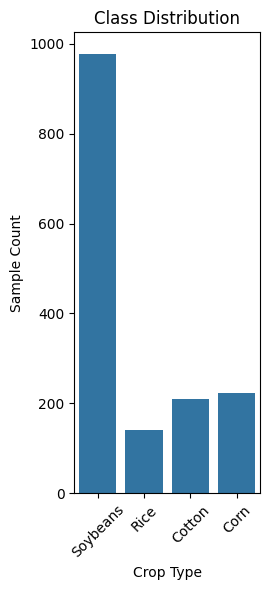

In [335]:
num_classes = df["cropland"].nunique()
plot_width = num_classes*0.7

plt.figure(figsize=(plot_width, 6))
sns.countplot(x="cropland", data=df)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.ylabel("Sample Count")
plt.xlabel("Crop Type")
plt.tight_layout()
plt.savefig(f"{dataset}-{tempo}-class-distribution.png")
plt.show()

In [336]:
if tempo == "multi":
  example_ids = (
      df.groupby(["cropland", "lon", "lat"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
      .drop_duplicates("cropland")
      .head(10)[["lon", "lat"]]
      .values
  )

  plt.figure(figsize=(24, 12))

  for lon, lat in example_ids:
      ts = df[(df["lon"] == lon) & (df["lat"] == lat)].sort_values("date")
      crop_label = ts["cropland"].iloc[0]
      plt.plot(ts["date"], ts["NDVI"], marker="o", label=f"{lon:.3f},{lat:.3f} (Crop {crop_label})")

  plt.legend()
  plt.xticks(rotation=45)
  plt.title("NDVI Time Series for 5 Different Crops", fontsize=14)
  plt.xlabel("Date", fontsize=12)
  plt.ylabel("NDVI", fontsize=12)
  plt.tight_layout()
  plt.savefig(f"{dataset}-{tempo}-NDVI-time-series.png")
  plt.show()

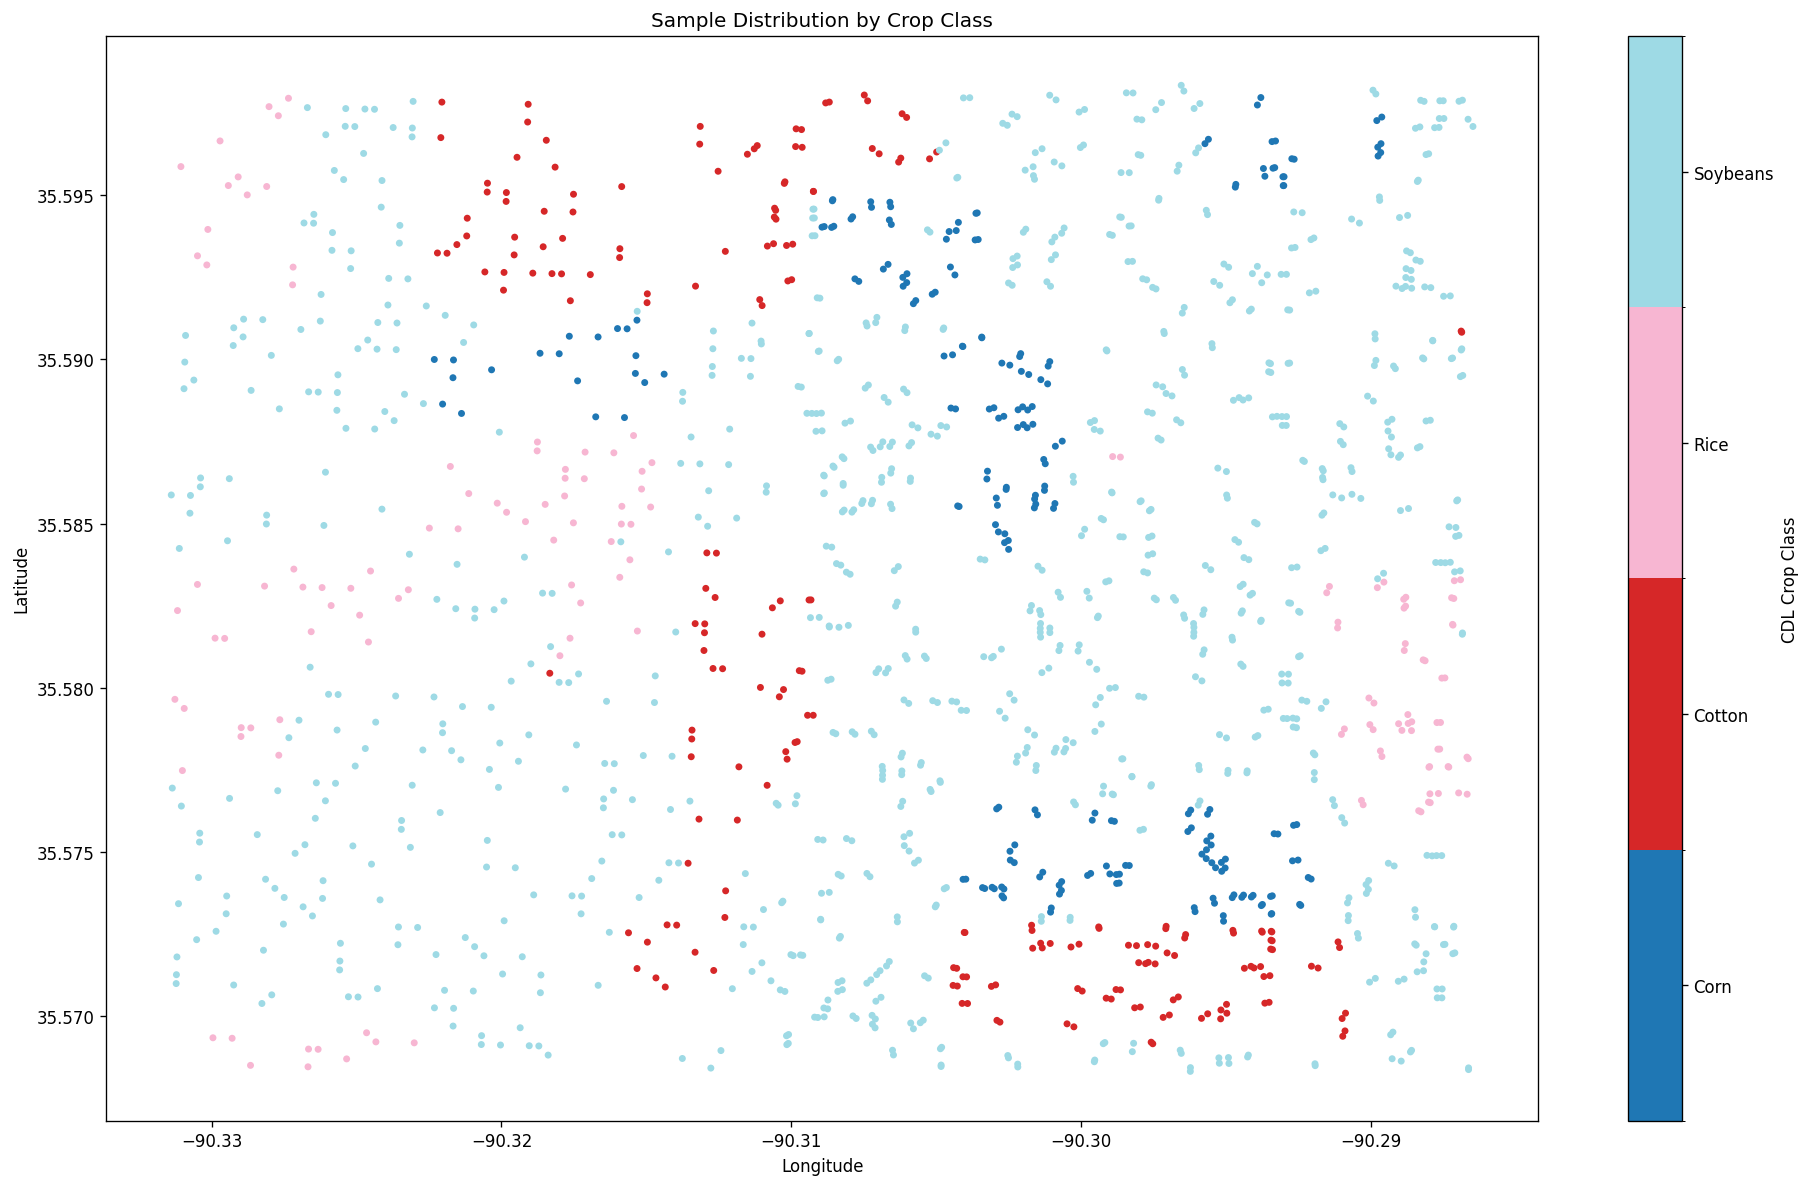

In [337]:
unique_crops = np.sort(df["cropland"].unique())

cmap = plt.get_cmap("tab20", len(unique_crops))
norm = mcolors.BoundaryNorm(boundaries=np.arange(len(unique_crops)+1)-0.5, ncolors=len(unique_crops))

plt.figure(figsize=(16, 10), dpi=120)
sc = plt.scatter(df["lon"], df["lat"], c=df["cropland"].map({v: i for i, v in enumerate(unique_crops)}),
                 cmap=cmap, norm=norm, s=10)

cbar = plt.colorbar(sc, ticks=range(len(unique_crops)))
cbar.ax.set_yticklabels(unique_crops)
cbar.set_label("CDL Crop Class")

plt.title("Sample Distribution by Crop Class")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(f"{dataset}-sample-distribution-by-crop-class.png")
plt.show()

In [338]:
center_lat = df["lat"].mean()
center_lon = df["lon"].mean()

# representing 20 stacked time-step observations for a single crop location throughout the year for every crop

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri, Maxar, Earthstar Geographics",
)

locations = df[["lat", "lon"]].values.tolist()

FastMarkerCluster(data=locations).add_to(m)

m.save("crop_points_map.html")
m


In [339]:
print("Min date:", df["date"].min())
print("Max date:", df["date"].max())

Min date: 2024-07-13 00:00:00
Max date: 2024-07-13 00:00:00


In [340]:
temporal_counts = df.groupby(["lon", "lat"])["date"].nunique()
print("Min #dates per location:", temporal_counts.min())
print("Max #dates per location:", temporal_counts.max())

Min #dates per location: 1
Max #dates per location: 1


In [341]:
if tempo == "multi":
  plt.figure(figsize=(16, 5))
  df["date"].hist(bins=100)
  plt.title("Distribution of Dates")
  plt.xlabel("Date")
  plt.ylabel("Number of Samples")
  plt.savefig(f"{dataset}-{tempo}-distribution-of-dates.png")
  plt.show()

In [342]:
# Check frequency between time points
if tempo == "multi":
  example = df.groupby(["lon", "lat"]).size().idxmax()

  df_sample = df[(df["lon"] == example[0]) & (df["lat"] == example[1])]

  print(df_sample["date"].diff().value_counts())

In [343]:
df.head(10)

,system:index,B2,B3,B4,B8,NDVI,cropland,date,lon,lat
0,20240713T163901_20240713T164929_T15SYV_988_0,972,853,501,4334,0.792761,Soybeans,2024-07-13,-90.296231,35.568320
1,20240713T163901_20240713T164929_T15SYV_975_0,941,795,454,4576,0.819483,Soybeans,2024-07-13,-90.286632,35.568375
2,20240713T163901_20240713T164929_T15SYV_1007_0,937,808,476,3919,0.783390,Soybeans,2024-07-13,-90.312775,35.568420
3,20240713T163901_20240713T164929_T16SBE_975_0,941,795,452,4565,0.819813,Soybeans,2024-07-13,-90.286631,35.568426
4,20240713T163901_20240713T164929_T16SBE_988_0,975,865,511,4356,0.790014,Soybeans,2024-07-13,-90.296227,35.568434
5,20240713T163901_20240713T164929_T15SYV_994_0,996,902,555,3786,0.744299,Soybeans,2024-07-13,-90.302184,35.568453
6,20240713T163901_20240713T164929_T15SYV_1010_0,990,891,536,3722,0.748239,Rice,2024-07-13,-90.326674,35.568459
7,20240713T163901_20240713T164929_T16SBE_993_0,1417,1448,1567,3145,0.334890,Soybeans,2024-07-13,-90.304832,35.568469
8,20240713T163901_20240713T164929_T15SYV_980_0,940,804,480,4321,0.800042,Soybeans,2024-07-13,-90.291923,35.568494
9,20240713T163901_20240713T164929_T15SYV_1009_0,1008,915,568,3367,0.711309,Rice,2024-07-13,-90.328658,35.568503


In [344]:
df.to_csv("exported_data.csv", index=False)

In [370]:
#--------------------DATA LOADING---------------------------

def load_multi_temporal_sequences(csv_path):
    df = pd.read_csv(csv_path)
    print("Filtered dataset loaded. Number of rows:", len(df))
    print("Unique crop types:", df["cropland"].unique())

    le = LabelEncoder()
    df["crop_id"] = le.fit_transform(df["cropland"])
    print("Unique crop labels:", le.classes_)

    grouped = df.groupby(["lon", "lat"])
    print("Number of locations:", len(grouped))

    X, y, coords = [], [], []
    for (lon, lat), group in grouped:
        group = group.sort_values("date")
        try:
            ndvi_seq = group["NDVI"].values.astype(np.float32)
            doy = pd.to_datetime(group["date"]).dt.dayofyear
            doy_sin = np.sin(2 * np.pi * doy / 365)
            doy_cos = np.cos(2 * np.pi * doy / 365)
            ndvi_delta = np.diff(ndvi_seq, prepend=ndvi_seq[0]).reshape(-1, 1)
            bands = group[["B2", "B3", "B4", "B8"]].values.astype(np.float32)

            features = np.concatenate([
                bands,
                ndvi_seq.reshape(-1, 1),
                ndvi_delta,
                doy_sin.to_numpy().reshape(-1, 1),
                doy_cos.to_numpy().reshape(-1, 1)
            ], axis=1)

            if np.count_nonzero(ndvi_seq) >= 10:
                X.append(features)
                y.append(group["crop_id"].iloc[0])
                coords.append((lon, lat))

        except Exception as e:
            print(f"Error processing group at ({lon}, {lat}):", str(e))

    y = np.array(y)
    print("Number of sequences collected:", len(X))
    print("First sequence shape:", X[0].shape)
    return X, y, coords, le


def load_mono_temporal_features(csv_path):
    df = pd.read_csv(csv_path)
    print("Loaded dataset with rows:", len(df))
    df = df.dropna(subset=["B2", "B3", "B4", "B8", "NDVI", "cropland"])

    le = LabelEncoder()
    df["crop_id"] = le.fit_transform(df["cropland"])
    print("Classes:", le.classes_)

    features = df[["B2", "B3", "B4", "B8", "NDVI"]].values.astype(np.float32)
    labels = df["crop_id"].values
    return features, labels, le


#---------------------------SPLITTING & SCALING--------------------


# one_hot=True  for Keras   models (LSTM, CNN)
# one_hot=False for sklearn models (RF, SVM)

def split_and_scale_sequences(X, y, coords, test_size=0.2, random_state=42, one_hot=True):  # CHANGED: added coords param

    groups = [f"{round(lon,3)}_{round(lat,3)}" for lon, lat in coords]
    gss = GroupShuffleSplit(test_size=test_size, random_state=random_state)
    idx_train, idx_val = next(gss.split(X, y, groups=groups))

    scaler = StandardScaler()
    scaler.fit(np.vstack([X[i] for i in idx_train]))
    X_scaled = [scaler.transform(seq) for seq in X]

    X_padded = pad_sequences(X_scaled, padding="post", dtype="float32")
    print("Padded X shape:", X_padded.shape)

    y_out = to_categorical(y) if one_hot else np.array(y)
    print("Encoded y shape:", y_out.shape)

    X_train, X_val = X_padded[idx_train], X_padded[idx_val]
    y_train, y_val = y_out[idx_train], y_out[idx_val]
    print("Training samples:", X_train.shape[0], "| Validation samples:", X_val.shape[0])

    return X_train, X_val, y_train, y_val, scaler


# one_hot=True reshapes to (n, 1, features), for Keras LSTM
def split_and_scale_flat(features, labels, test_size=0.2, random_state=42, one_hot=True):
    idx_train, idx_val = train_test_split(np.arange(len(features)), test_size=test_size, random_state=random_state, stratify=labels)

    scaler = StandardScaler()
    scaler.fit(features[idx_train])                    # fit on train only
    features_scaled = scaler.transform(features)        # apply to everything

    if one_hot:
        X = features_scaled.reshape(-1, 1, features.shape[1])
        y = to_categorical(labels)
    else:
        X = features_scaled
        y = np.array(labels)

    X_train, X_val = X[idx_train], X[idx_val]
    y_train, y_val = y[idx_train], y[idx_val]

    return X_train, X_val, y_train, y_val, scaler


#-----------------------CLASS WEIGHTING------------------------

def compute_class_weights(y_int_labels):
    weights = class_weight.compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_int_labels),
        y=y_int_labels
    )
    return dict(enumerate(weights))


#-----------------------TRAINING & EVALUATION, KERAS MODELS (LSTM, CNN)------------------------

def train_model(model, X_train, y_train, X_val, y_val, class_weights, batch_size, epochs=20):
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        class_weight=class_weights,
        verbose=1
    )
    return history


def evaluate_model(model, X_val, y_val, le, model_name):
    y_pred = model.predict(X_val)
    y_val_labels = np.argmax(y_val, axis=1)
    y_pred_labels = np.argmax(y_pred, axis=1)

    labels = range(len(le.classes_))
    report_str = classification_report(y_val_labels, y_pred_labels, labels=labels, target_names=le.classes_, zero_division=0)
    print(report_str)

    with open(f"{dataset}-{tempo}-{model_name}-classification-report.txt", "w") as f:
        f.write(report_str)

    report = classification_report(y_val_labels, y_pred_labels, labels=labels, target_names=le.classes_, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).transpose()
    report_df = report_df.iloc[:-3]  # drop accuracy, macro avg, weighted avg rows

    return report_df, y_val_labels, y_pred_labels


#-----------------------TRAINING & EVALUATION, SKLEARN MODELS (RF, SVM)------------------------


def evaluate_sklearn_model(model, X_val, y_val, le, model_name, drop_summary_rows=True):
    y_pred = model.predict(X_val)
    labels = range(len(le.classes_))  # force all classes, even ones absent from y_val
    report_str = classification_report(y_val, y_pred, labels=labels, target_names=le.classes_, zero_division=0)
    print(report_str)

    with open(f"{dataset}-{tempo}-{model_name}-classification-report.txt", "w") as f:
        f.write(report_str)

    report = classification_report(y_val, y_pred, labels=labels, target_names=le.classes_, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).transpose()
    if drop_summary_rows:
        report_df = report_df.iloc[:-3]
    return report_df, y_pred


#------------------------PLOTTING-----------------------

def plot_classification_report(report_df, model_name, title="Classification Report"):
    report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(14, 6))
    plt.title(title)
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.grid(True)
    plt.savefig(f"{dataset}-{tempo}-{model_name}-classification-report.png")
    plt.show()


def plot_confusion(y_val_labels, y_pred_labels, le, model_name, title="Confusion Matrix"):
    num_classes = len(le.classes_)
    cm = confusion_matrix(y_val_labels, y_pred_labels, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(num_classes, num_classes))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{dataset}-{tempo}-{model_name}-confusion-matrix.png")
    plt.show()


#-----------------------MODEL ARCHITECTURES------------------------

def build_lstm_multi(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Masking(mask_value=0.0)(inputs)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = LayerNormalization()(x)
    x = Dropout(0.3)(x)
    attn_out = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = LayerNormalization()(x + attn_out)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("gelu")(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_lstm_mono(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(64, return_sequences=True)),
        LayerNormalization(),
        Dropout(0.3),
        LSTM(32),
        LayerNormalization(),
        Dense(32, use_bias=False),
        BatchNormalization(),
        Activation("gelu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_cnn_multi(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Masking(mask_value=0.0)(inputs)

    x = Conv1D(64, kernel_size=3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('gelu')(x)
    x = Dropout(0.3)(x)

    x = Conv1D(128, kernel_size=3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('gelu')(x)

    gap = GlobalAveragePooling1D()(x)
    gmp = GlobalMaxPooling1D()(x)
    x = Concatenate()([gap, gmp])

    x = Dense(64, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('gelu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_cnn_mono(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Masking(mask_value=0.0)(inputs)

    x = Conv1D(64, kernel_size=3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('gelu')(x)
    x = Dropout(0.3)(x)

    x = Conv1D(128, kernel_size=3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('gelu')(x)

    gap = GlobalAveragePooling1D()(x)
    gmp = GlobalMaxPooling1D()(x)
    x = Concatenate()([gap, gmp])

    x = Dense(64, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('gelu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

Loaded dataset with rows: 1549
Classes: ['Corn' 'Cotton' 'Rice' 'Soybeans']
              precision    recall  f1-score   support

        Corn       0.79      0.86      0.83        44
      Cotton       0.93      0.90      0.92        42
        Rice       0.83      0.54      0.65        28
    Soybeans       0.90      0.93      0.92       196

    accuracy                           0.88       310
   macro avg       0.86      0.81      0.83       310
weighted avg       0.88      0.88      0.88       310



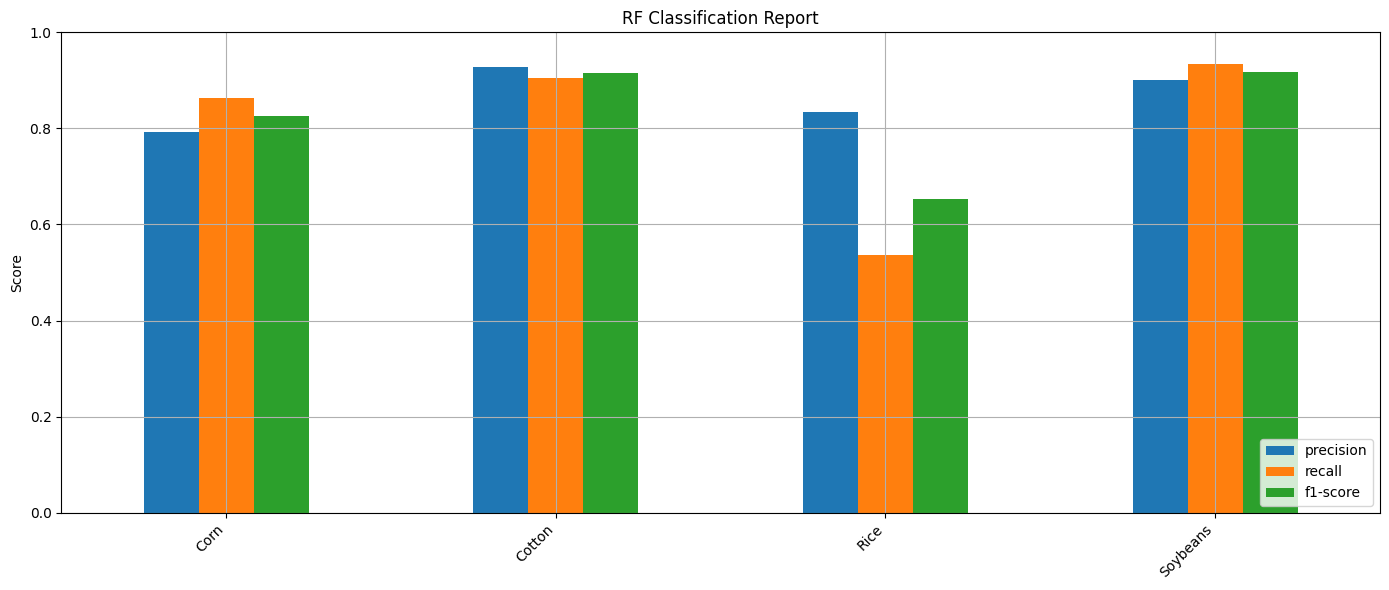

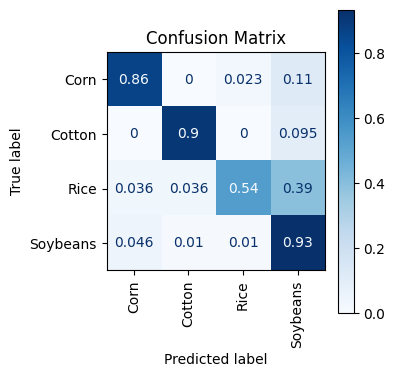

In [371]:
# rf
if tempo == "multi":
    X, y, coords, le = load_multi_temporal_sequences("exported_data.csv")
    X_train, X_val, y_train, y_val, scaler = split_and_scale_sequences(X, y, coords, one_hot=False)

    # RF needs 2D input, flattened
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_val = X_val.reshape(X_val.shape[0], -1)

    class_weights = compute_class_weights(y_train)

    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight=class_weights,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    report_df, y_pred = evaluate_sklearn_model(rf, X_val, y_val, le, "rf")

elif tempo == "mono":
    features, labels, le = load_mono_temporal_features("exported_data.csv")
    X_train, X_val, y_train, y_val, scaler = split_and_scale_flat(features, labels, one_hot=False)

    class_weights = compute_class_weights(y_train)

    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight=class_weights,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    report_df, y_pred = evaluate_sklearn_model(rf, X_val, y_val, le, "rf")

plot_classification_report(report_df, model_name="rf", title="RF Classification Report")
plot_confusion(y_val, y_pred, le, model_name="rf", title="Confusion Matrix")

Loaded dataset with rows: 1549
Classes: ['Corn' 'Cotton' 'Rice' 'Soybeans']
              precision    recall  f1-score   support

        Corn       0.47      0.98      0.64        44
      Cotton       0.67      0.95      0.78        42
        Rice       0.34      0.71      0.47        28
    Soybeans       0.98      0.51      0.67       196

    accuracy                           0.65       310
   macro avg       0.62      0.79      0.64       310
weighted avg       0.81      0.65      0.66       310



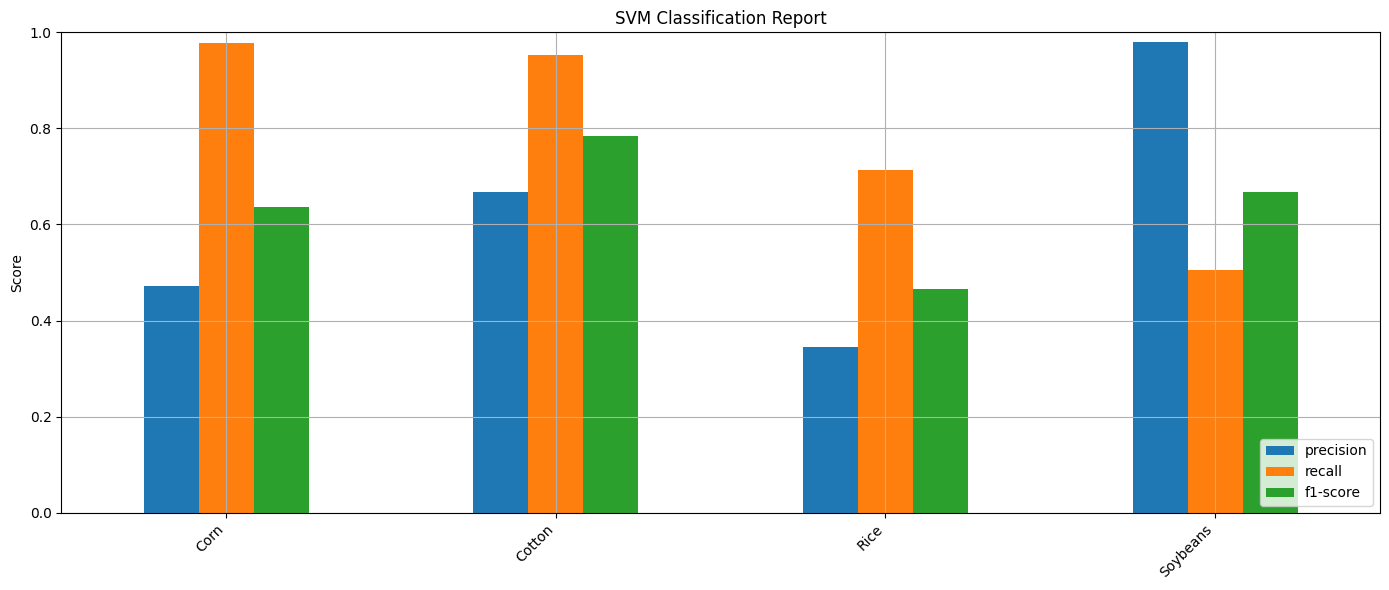

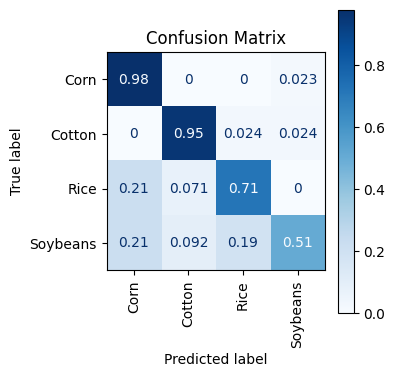

In [372]:
# svm
if tempo == "multi":
    X, y, coords, le = load_multi_temporal_sequences("exported_data.csv")
    X_train, X_val, y_train, y_val, scaler = split_and_scale_sequences(X, y, coords, one_hot=False)


    # SVC needs 2D input, flattened
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_val = X_val.reshape(X_val.shape[0], -1)

    class_weights_dict = compute_class_weights(y_train)

    svm = SVC(kernel='rbf', class_weight=class_weights_dict)
    svm.fit(X_train, y_train)

    report_df, y_pred = evaluate_sklearn_model(svm, X_val, y_val, le, "svm")

elif tempo == "mono":
    features, labels, le = load_mono_temporal_features("exported_data.csv")
    X_train, X_val, y_train, y_val, scaler = split_and_scale_flat(features, labels, one_hot=False)  # CHANGED

    # X is already 2D, y is already plain integers
    class_weights_dict = compute_class_weights(y_train)

    svm = SVC(kernel='rbf', class_weight=class_weights_dict)
    svm.fit(X_train, y_train)

    report_df, y_pred = evaluate_sklearn_model(svm, X_val, y_val, le, "svm")

plot_classification_report(report_df, "svm", title="SVM Classification Report")
plot_confusion(y_val, y_pred, le, "svm", title="Confusion Matrix")

Loaded dataset with rows: 1549
Classes: ['Corn' 'Cotton' 'Rice' 'Soybeans']


Model: "functional_47"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_49      │ (None, 5, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_35          │ (None, 5, 1)      │          0 │ input_layer_49[0… │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_53 (Conv1D)  │ (None, 5, 64)     │        192 │ masking_35[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 64)     │        256 │ conv1d_53[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_67       │ (None, 5, 64)     │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_93          │ (None, 5, 64)     │          0 │ activation_67[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_54 (Conv1D)  │ (None, 5, 128)    │     24,576 │ dropout_93[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 128)    │        512 │ conv1d_54[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_68       │ (None, 5, 128)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_68[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ activation_68[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_19      │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_97 (Dense)    │ (None, 64)        │     16,384 │ concatenate_19[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_97[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_69       │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_94          │ (None, 64)        │          0 │ activation_69[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_98 (Dense)    │ (None, 4)         │        260 │ dropout_94[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,436 (165.77 KB)

 Trainable params: 41,924 (163.77 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4762 - loss: 1.0433 - val_accuracy: 0.2129 - val_loss: 1.4080 - learning_rate: 0.0010
Epoch 2/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5593 - loss: 0.8964 - val_accuracy: 0.2516 - val_loss: 1.3730 - learning_rate: 0.0010
Epoch 3/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5868 - loss: 0.8177 - val_accuracy: 0.3290 - val_loss: 1.3389 - learning_rate: 0.0010
Epoch 4/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6174 - loss: 0.7541 - val_accuracy: 0.3484 - val_loss: 1.2788 - learning_rate: 0.0010
Epoch 5/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6215 - loss: 0.7182 - val_accuracy: 0.5161 - val_loss: 1.1947 - learning_rate: 0.0010
Epoch 6/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6247 - loss: 0.7378 - val_accuracy: 0.4677 - val_loss: 1.1671 - learning_rate: 0.0010
Epoch 7/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6303 - loss: 0.7354 - val_acc

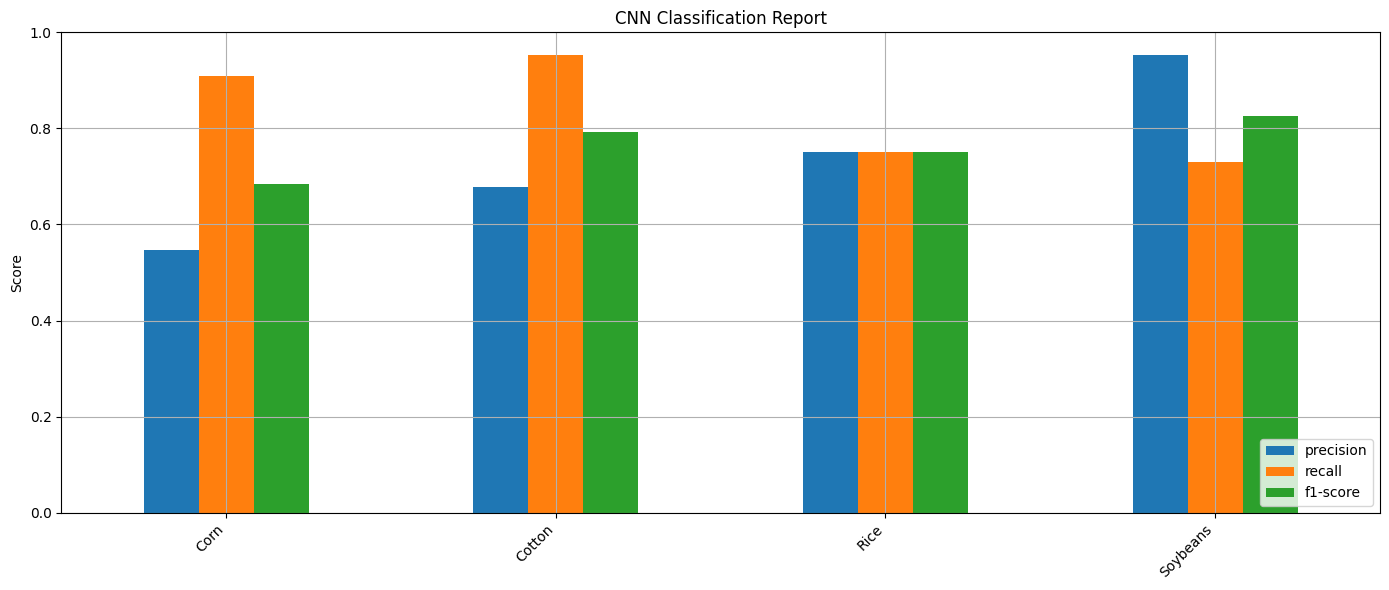

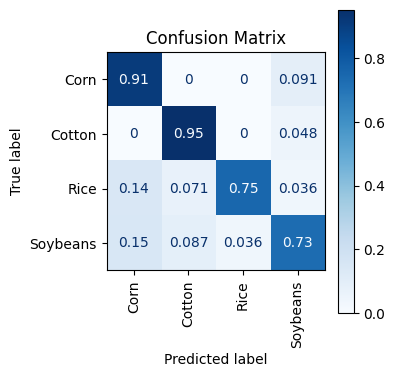

In [373]:
# cnn
if tempo == "multi":
    X, y, coords, le = load_multi_temporal_sequences("exported_data.csv")
    X_train, X_val, y_train, y_val, scaler = split_and_scale_sequences(X, y, coords, one_hot=True)

    class_weights = compute_class_weights(y)

    model = build_cnn_multi(input_shape=(X_train.shape[1], X_train.shape[2]),
                             num_classes=y_train.shape[1])
    model.summary()

    train_model(model, X_train, y_train, X_val, y_val, class_weights, batch_size=32, epochs=80)

    report_df, y_val_labels, y_pred_labels = evaluate_model(model, X_val, y_val, le, "cnn")
    report_df = report_df.iloc[:-3]

elif tempo == "mono":
    features, labels, le = load_mono_temporal_features("exported_data.csv")

    idx_train, idx_val = train_test_split(
        np.arange(len(features)), test_size=0.2, random_state=42, stratify=labels
    )
    scaler = StandardScaler()
    scaler.fit(features[idx_train])
    X_scaled = scaler.transform(features)
    X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
    y_encoded = to_categorical(labels)

    X_train, X_val = X_reshaped[idx_train], X_reshaped[idx_val]
    y_train, y_val = y_encoded[idx_train], y_encoded[idx_val]

    class_weights = compute_class_weights(labels)

    model = build_cnn_mono(input_shape=(X_train.shape[1], 1),
                            num_classes=y_train.shape[1])
    model.summary()

    train_model(model, X_train, y_train, X_val, y_val, class_weights, batch_size=32, epochs=80)

    report_df, y_val_labels, y_pred_labels = evaluate_model(model, X_val, y_val, le, "cnn")

plot_classification_report(report_df, "cnn", title="CNN Classification Report")
plot_confusion(y_val_labels, y_pred_labels, le, "cnn", title="Confusion Matrix")

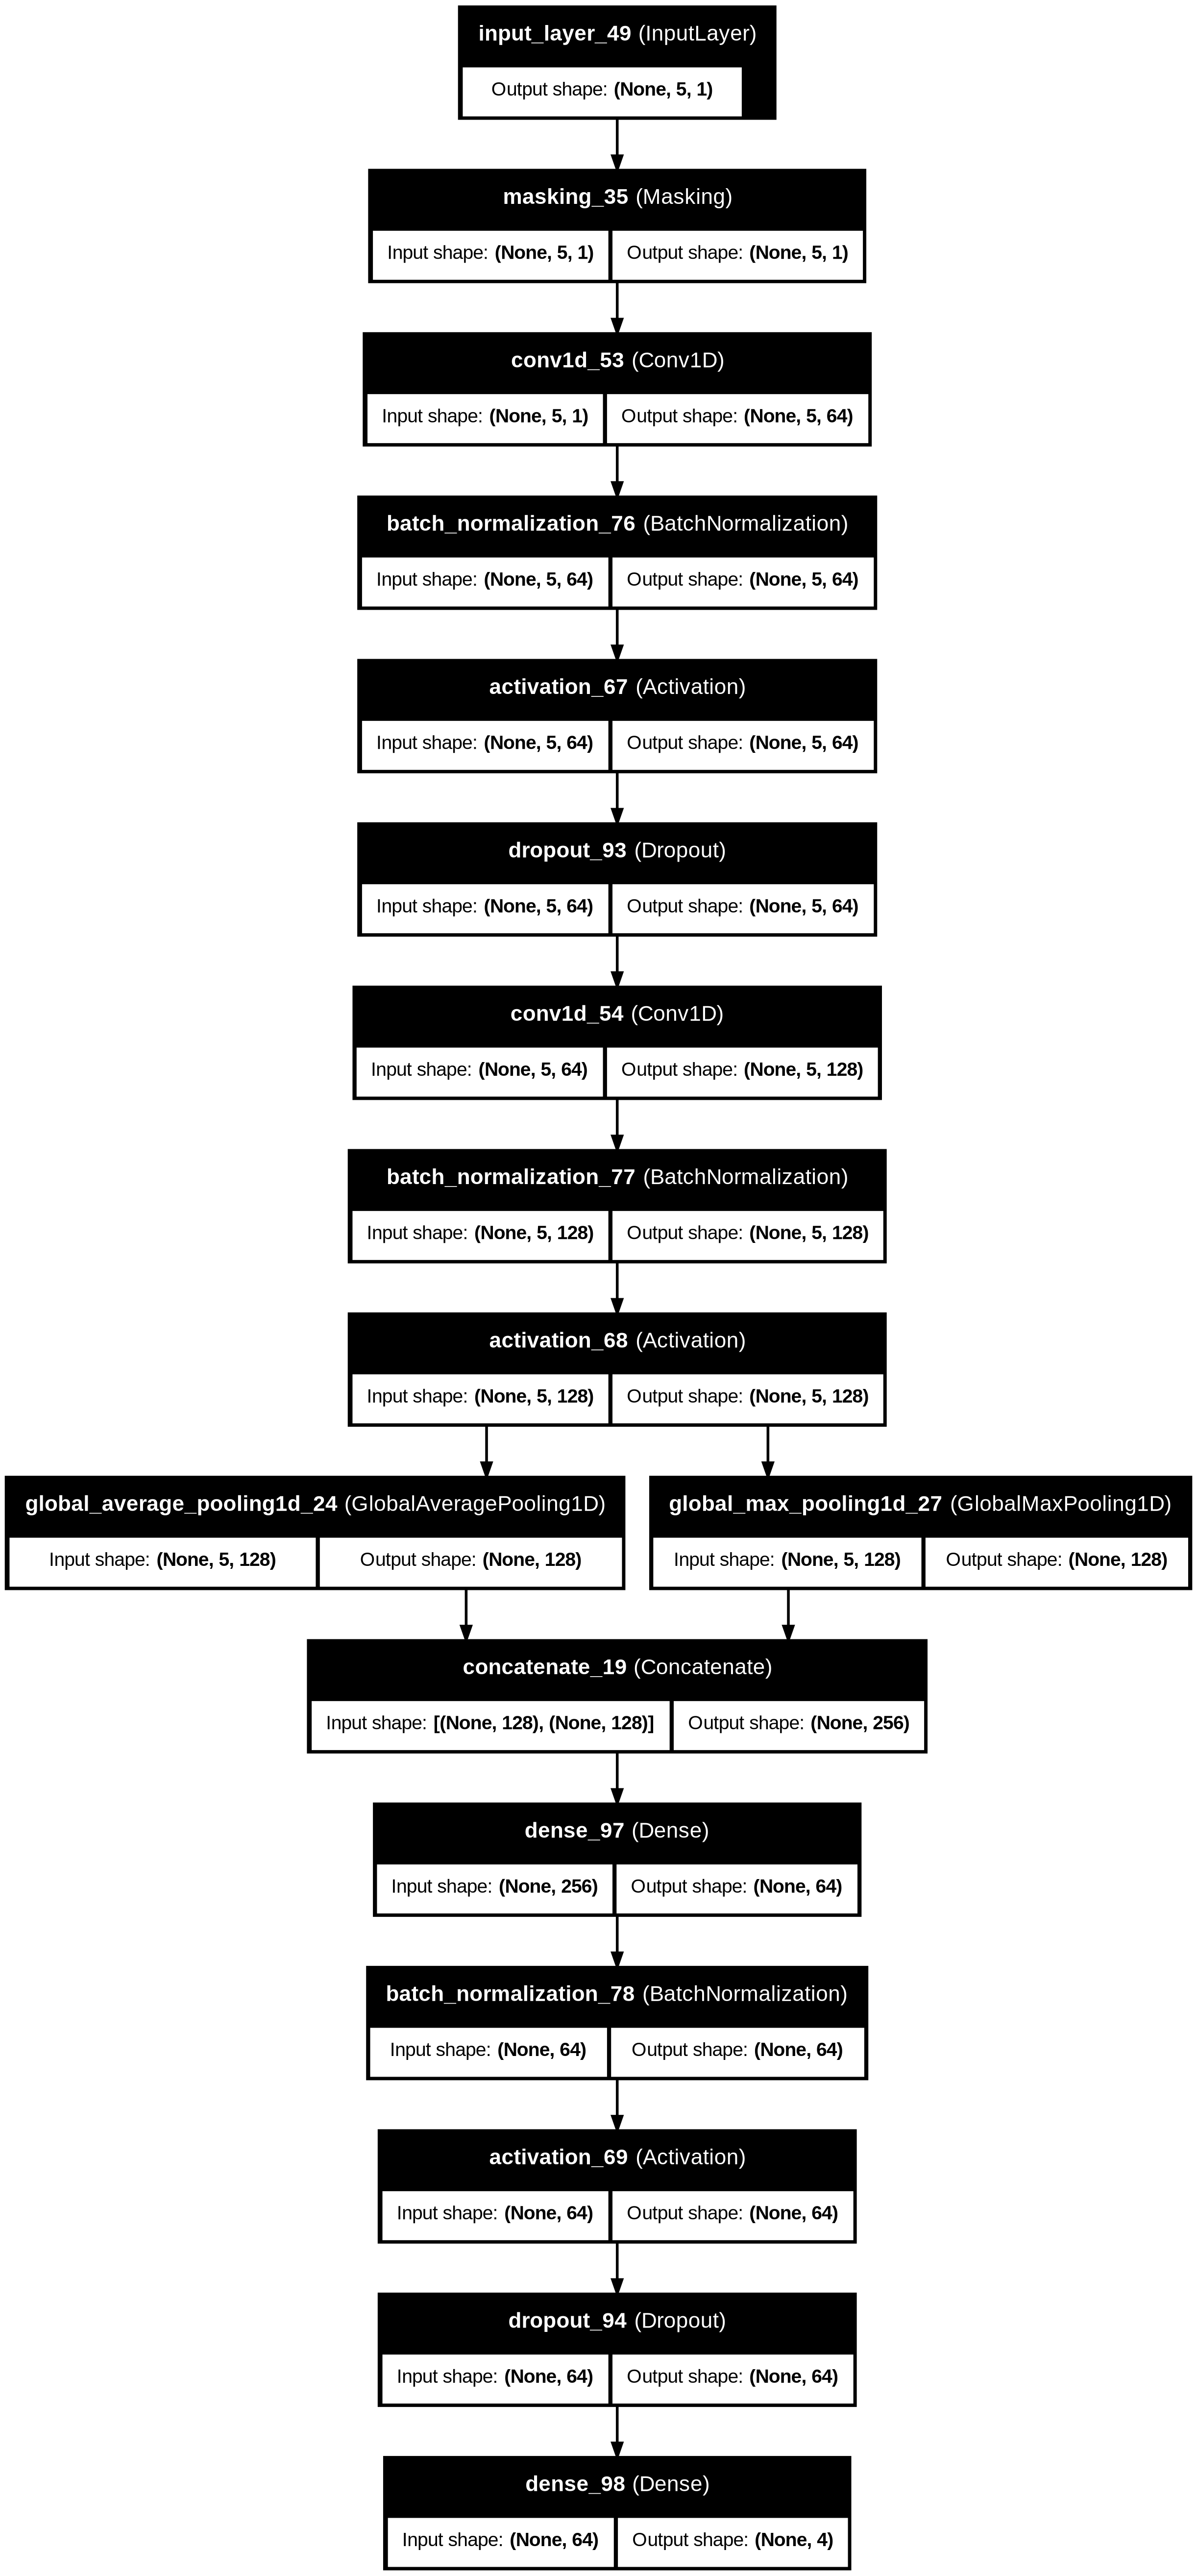

In [374]:
plot_model(model, show_shapes=True, show_layer_names=True, to_file=f"{dataset}-{tempo}-cnn--model-architecture.png")

Loaded dataset with rows: 1549
Classes: ['Corn' 'Cotton' 'Rice' 'Soybeans']


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_23                │ (None, 1, 128)         │        35,840 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_26          │ (None, 1, 128)         │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_95 (Dropout)            │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_27          │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 32)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_79          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_70 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,052 (226.77 KB)

 Trainable params: 57,988 (226.52 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.4867 - loss: 1.0159 - val_accuracy: 0.4710 - val_loss: 1.1126 - learning_rate: 0.0010
Epoch 2/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5577 - loss: 0.8233 - val_accuracy: 0.4839 - val_loss: 1.0429 - learning_rate: 0.0010
Epoch 3/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5868 - loss: 0.7531 - val_accuracy: 0.5839 - val_loss: 0.8416 - learning_rate: 0.0010
Epoch 4/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6344 - loss: 0.7143 - val_accuracy: 0.6065 - val_loss: 0.8047 - learning_rate: 0.0010
Epoch 5/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6788 - loss: 0.6288 - val_accuracy: 0.7355 - val_loss: 0.6321 - learning_rate: 0.0010
Epoch 6/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6941 - loss: 0.6322 - val_accuracy: 0.6871 - val_loss: 0.6723 - learning_rate: 0.0010
Epoch 7/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7022 - loss: 0.6161 - val_acc

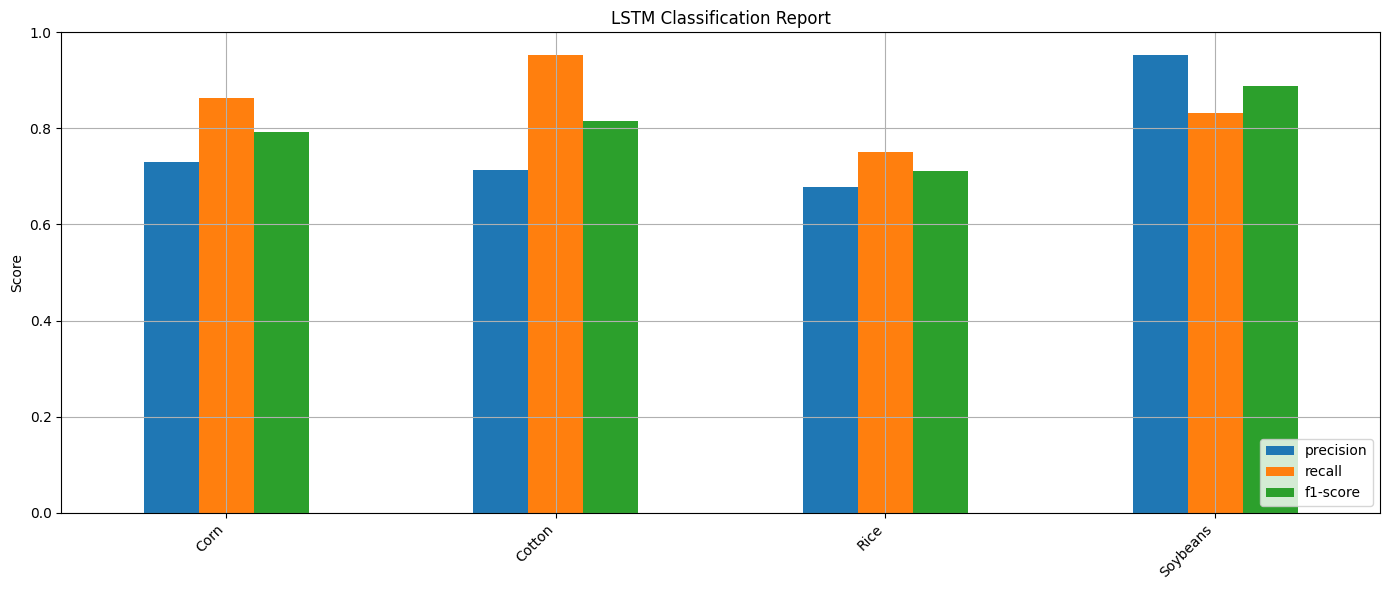

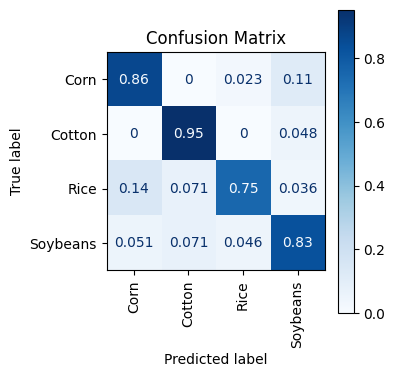

In [375]:
# lstm

if tempo == "multi":
    X, y, coords, le = load_multi_temporal_sequences("exported_data.csv")
    X_train, X_val, y_train, y_val, scaler = split_and_scale_sequences(X, y, coords, one_hot=True)
    class_weights = compute_class_weights(y)

    model = build_lstm_multi(input_shape=(X_train.shape[1], X_train.shape[2]),
                              num_classes=y_train.shape[1])
    model.summary()

    train_model(model, X_train, y_train, X_val, y_val, class_weights, batch_size=32, epochs=80)

    print("Sample prediction on one validation instance:")
    print(model.predict(X_val[:1]))

    report_df, y_val_labels, y_pred_labels = evaluate_model(model, X_val, y_val, le, "lstm")

elif tempo == "mono":
    features, labels, le = load_mono_temporal_features("exported_data.csv")
    X_train, X_val, y_train, y_val, scaler = split_and_scale_flat(features, labels)
    class_weights = compute_class_weights(labels)

    model = build_lstm_mono(input_shape=(X_train.shape[1], X_train.shape[2]),
                             num_classes=y_train.shape[1])
    model.summary()

    train_model(model, X_train, y_train, X_val, y_val, class_weights, batch_size=32, epochs=80)

    report_df, y_val_labels, y_pred_labels = evaluate_model(model, X_val, y_val, le, "lstm")

plot_classification_report(report_df, "lstm", title="LSTM Classification Report")
plot_confusion(y_val_labels, y_pred_labels, le, "lstm", title="Confusion Matrix")

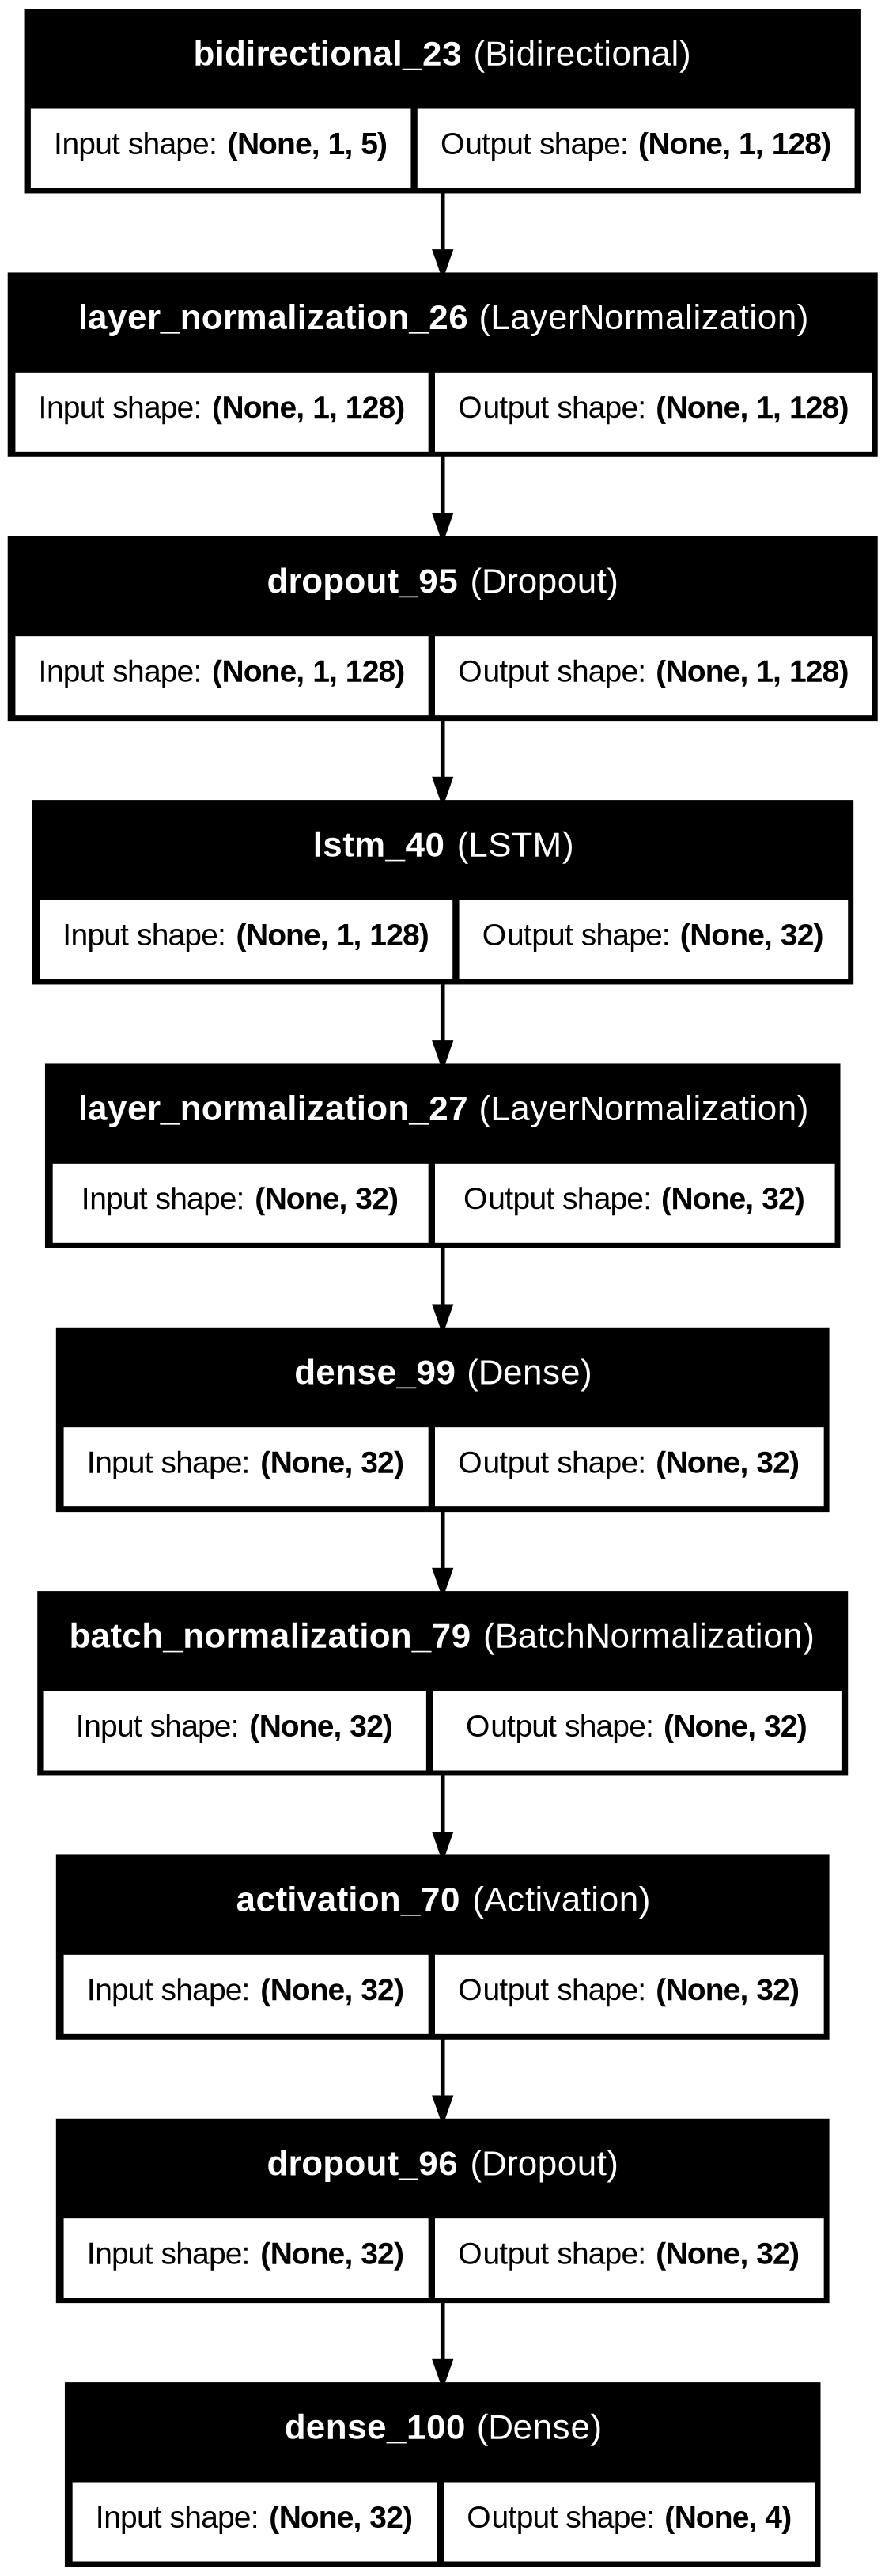

In [376]:
plot_model(model, show_shapes=True, show_layer_names=True, to_file=f"{dataset}-{tempo}-lstm--model-architecture.png")